In [1]:
# imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.io as sio
import h5py

In [4]:
from matplotlib.font_manager import fontManager, FontProperties
fpath = "Figure_data/MYRIADPRO-REGULAR.OTF"
fontManager.addfont(fpath)
prop = FontProperties(fname=fpath)

# Predition results

## Model performance

In [12]:
# load performance data of prediction models
PPdata_G1 = sio.loadmat('Figure_data/ART_G1_PrePerfomance.mat')
PPdata_G2 = sio.loadmat('Figure_data/ART_G2_PrePerfomance.mat')
# load predicted timeseries data
TSPredata = sio.loadmat('Figure_data/PreTS_lvls.mat')

In [13]:
# build dataframe for overall performance
df_PPG1 = pd.DataFrame({'SubID':np.tile(range(1,35),4),
                        'Truelvls':np.repeat([1,2,3,4],34).reshape((-1,1))[:,0],
                        'Predictlvls':PPdata_G1['predicted_ratings_reshaped'].reshape((-1,1), order='F')[:,0]})
df_PPG2 = pd.DataFrame({'SubID':np.tile(range(1,35),4),
                        'Truelvls':np.repeat([1,2,3,4],34).reshape((-1,1))[:,0],
                        'Predictlvls':PPdata_G2['predicted_ratings_reshaped'].reshape((-1,1), order='F')[:,0]})

/var/folders/2q/v8k7f8yj5jg6mtyx9v4xzr340000gn/T/ipykernel_63592/2456605304.py:2: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 3}` instead.

  ax = sns.catplot(data=df_PPG1,x="Truelvls",y="Predictlvls",color ="#b8262b",kind='point', capsize=.2,errwidth=3, markers="o", linestyles="-", errorbar="se",height=9,aspect=0.95)


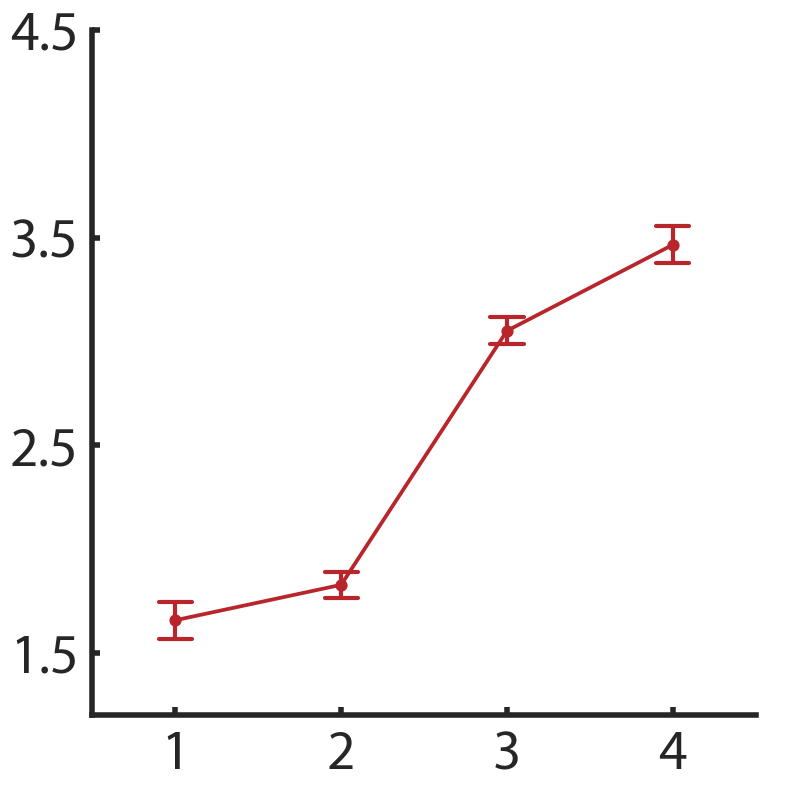

In [14]:
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(8,6)},font=prop.get_name())
ax = sns.catplot(data=df_PPG1,x="Truelvls",y="Predictlvls",color ="#b8262b",kind='point', capsize=.2,errwidth=3, markers="o", linestyles="-", errorbar="se",height=9,aspect=0.95)
ax.set(xlabel='', ylabel='')
ax.set(ylim=(1.2,4), yticks=[1.5,2.5,3.5,4.5])
ax.tick_params(axis="y",direction="in", pad=10, labelsize=40)
ax.tick_params(axis="x",direction="in", pad=10, labelsize=40)
for axs in ax.axes.flat:
    axs.spines["left"].set_linewidth(4)  # Left axis
    axs.spines["bottom"].set_linewidth(4) # Bottom axis
ax.tick_params(width=4)
sns.despine()


/var/folders/2q/v8k7f8yj5jg6mtyx9v4xzr340000gn/T/ipykernel_63592/900754293.py:2: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 3}` instead.

  ax = sns.catplot(data=df_PPG2,x="Truelvls",y="Predictlvls",color ="#b8262b",kind='point', capsize=.2,errwidth=3, markers="o", linestyles="-", errorbar="se",height=9,aspect=0.95)


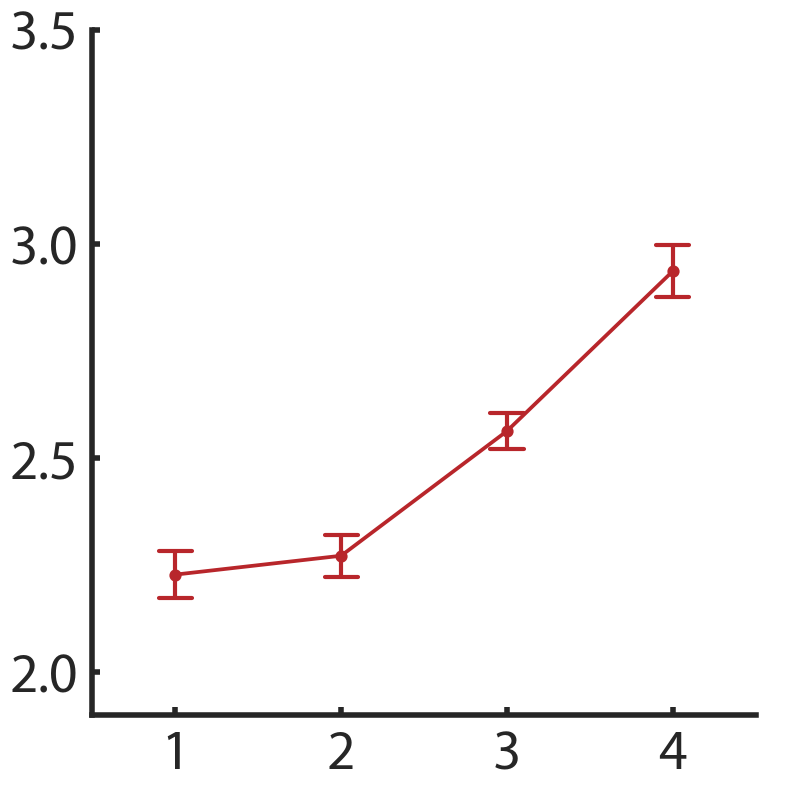

In [15]:
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(8,6)},font=prop.get_name())
ax = sns.catplot(data=df_PPG2,x="Truelvls",y="Predictlvls",color ="#b8262b",kind='point', capsize=.2,errwidth=3, markers="o", linestyles="-", errorbar="se",height=9,aspect=0.95)
ax.set(xlabel='', ylabel='')
ax.set(ylim=(1.9,3.5), yticks=[2,2.5,3,3.5])
ax.tick_params(axis="y",direction="in", pad=10, labelsize=40)
ax.tick_params(axis="x",direction="in", pad=10, labelsize=40)
for axs in ax.axes.flat:
    axs.spines["left"].set_linewidth(4)  # Left axis
    axs.spines["bottom"].set_linewidth(4) # Bottom axis
ax.tick_params(width=4)
sns.despine()

In [16]:
from matplotlib.colors import LinearSegmentedColormap
def truncate_colormap(cmap, min_val=0.0, max_val=1.0, n=100):
    """Truncate a colormap to use only a portion of its range."""
    new_cmap = LinearSegmentedColormap.from_list(
        "truncated", cmap(np.linspace(min_val, max_val, n))
    )
    return new_cmap

In [17]:
slopes = {}
for group in df_PPG1['SubID'].unique():
    group_data = df_PPG1[df_PPG1['SubID'] == group]
    slope = np.corrcoef(group_data['Truelvls'], group_data['Predictlvls']) # correlation
    slopes[group] = slope[0,1]
norm = plt.Normalize(vmin=-1, vmax=1)
cmap = plt.cm.coolwarm  # Choose a colormap
colors_g1 = {group: cmap(norm(slope)) for group, slope in slopes.items()}

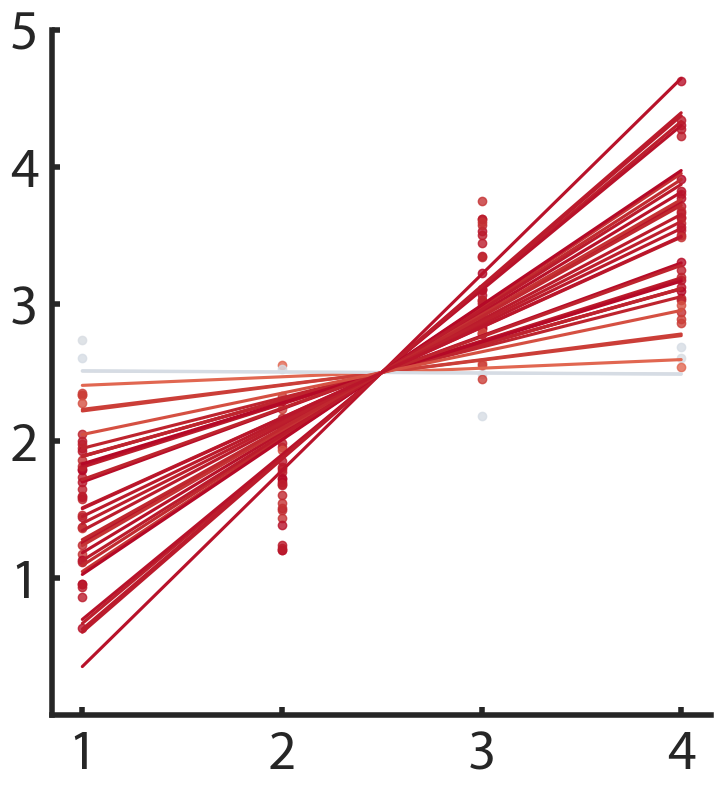

In [18]:
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(8,6)},font=prop.get_name())
ax = sns.lmplot(data=df_PPG1, x="Truelvls", y="Predictlvls", hue="SubID",legend=False,palette=colors_g1,ci=None,height=9,aspect=0.95)
ax.set(xlabel='', ylabel='')
ax.set(ylim=(0,5), yticks=[1,2,3,4,5])
ax.set(xticks=[1,2,3,4])
ax.tick_params(axis="y",direction="in", pad=10, labelsize=40)
ax.tick_params(axis="x",direction="in", pad=10, labelsize=40)
for axs in ax.axes.flat:
    axs.spines["left"].set_linewidth(4)  # Left axis
    axs.spines["bottom"].set_linewidth(4) # Bottom axis
ax.tick_params(width=4)
sns.despine()

In [19]:
from scipy.stats import linregress
slopes = {}
for group in df_PPG2['SubID'].unique():
    group_data = df_PPG2[df_PPG2['SubID'] == group]
    slope, _, _, _, _ = linregress(group_data['Truelvls'], group_data['Predictlvls'])  # Linear regression
    slopes[group] = slope
norm = plt.Normalize(vmin=-1, vmax=1)
cmap = plt.cm.coolwarm  # Choose a colormap
colors_g2 = {group: cmap(norm(slope)) for group, slope in slopes.items()}

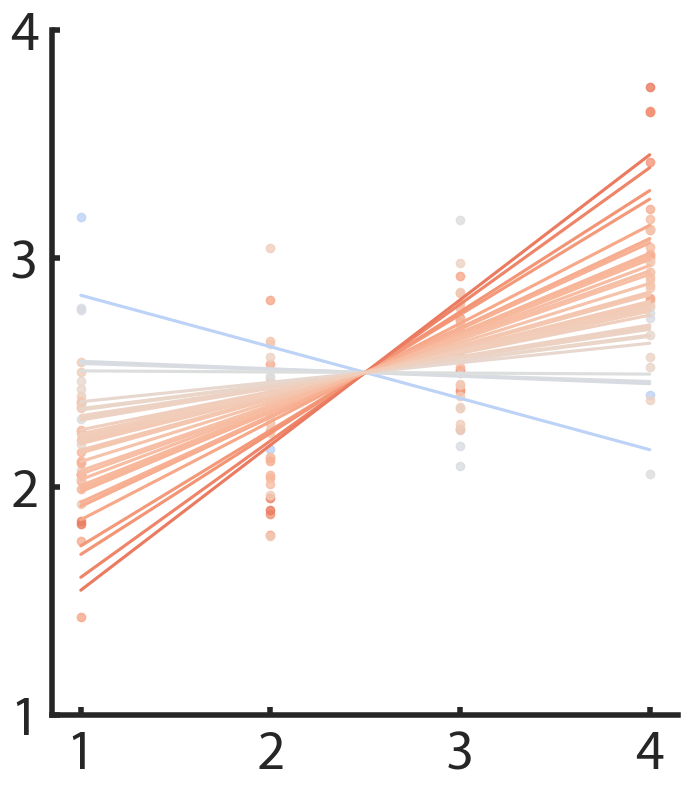

In [20]:
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(8,6)},font=prop.get_name())
ax = sns.lmplot(data=df_PPG2, x="Truelvls", y="Predictlvls", hue="SubID",legend=False,palette=colors_g2,ci=None,height=9,aspect=0.95)
ax.set(xlabel='', ylabel='')
ax.set(ylim=(1,4), yticks=[1,2,3,4])
ax.set(xticks=[1,2,3,4])
ax.tick_params(axis="y",direction="in", pad=10, labelsize=40)
ax.tick_params(axis="x",direction="in", pad=10, labelsize=40)
for axs in ax.axes.flat:
    axs.spines["left"].set_linewidth(4)  # Left axis
    axs.spines["bottom"].set_linewidth(4) # Bottom axis
ax.tick_params(width=4)
sns.despine()

In [21]:
df_TSpre_g1 = pd.DataFrame({'TSlvls':np.repeat(range(1,16),34).reshape((-1,1))[:,0],
                        'TSlvl1':TSPredata['PreTS_lvls_g1'][0][0].reshape((-1,1), order='F')[:,0],
                        'TSlvl2':TSPredata['PreTS_lvls_g1'][0][1].reshape((-1,1), order='F')[:,0],
                        'TSlvl3':TSPredata['PreTS_lvls_g1'][0][2].reshape((-1,1), order='F')[:,0],
                        'TSlvl4':TSPredata['PreTS_lvls_g1'][0][3].reshape((-1,1), order='F')[:,0],})
df_TSpre_g2 = pd.DataFrame({'TSlvls':np.repeat(range(1,16),34).reshape((-1,1))[:,0],
                        'TSlvl1':TSPredata['PreTS_lvls_g2'][0][0].reshape((-1,1), order='F')[:,0],
                        'TSlvl2':TSPredata['PreTS_lvls_g2'][0][1].reshape((-1,1), order='F')[:,0],
                        'TSlvl3':TSPredata['PreTS_lvls_g2'][0][2].reshape((-1,1), order='F')[:,0],
                        'TSlvl4':TSPredata['PreTS_lvls_g2'][0][3].reshape((-1,1), order='F')[:,0],})

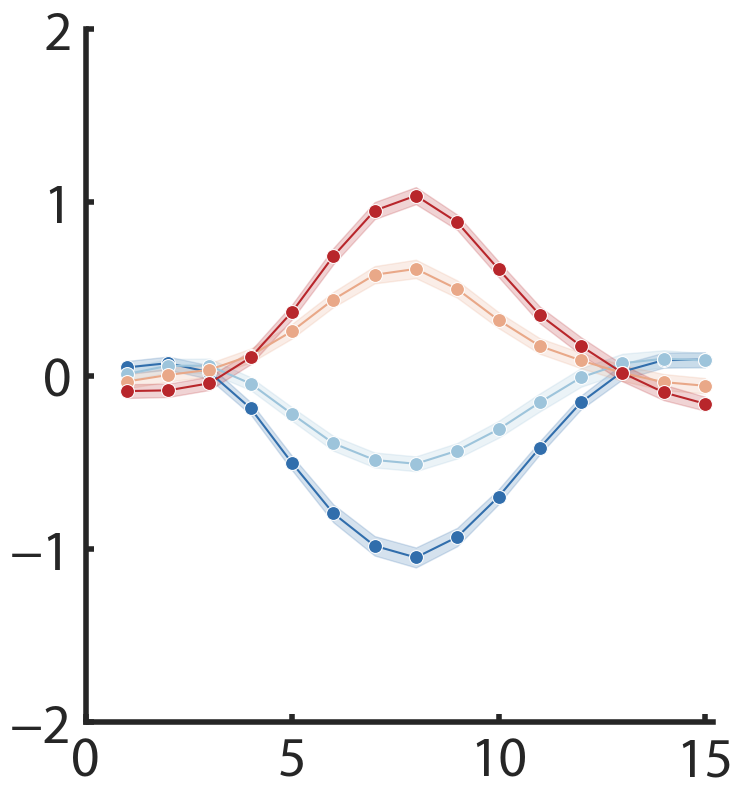

In [22]:
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(7,8)},font=prop.get_name())
fig, ax = plt.subplots(figsize=(9*0.9,9))  
sns.lineplot(x="TSlvls", y="TSlvl1", data=df_TSpre_g1,marker="o",markersize=10,errorbar='se',color="#316eac")
sns.lineplot(x="TSlvls", y="TSlvl2", data=df_TSpre_g1,marker="o",markersize=10,errorbar='se',color="#9dc4db")
sns.lineplot(x="TSlvls", y="TSlvl3", data=df_TSpre_g1,marker="o",markersize=10,errorbar='se',color="#e9a888")
sns.lineplot(x="TSlvls", y="TSlvl4", data=df_TSpre_g1,marker="o",markersize=10,errorbar='se',color="#b8262b")
ax.set(xlabel='', ylabel='')
ax.set(ylim=(-2,2), yticks=[-2,-1,0,1,2])
ax.set(xlim=(0,15.2), xticks=[0,5,10,15])
ax.tick_params(axis="y",direction="in", pad=10, labelsize=40)
ax.tick_params(axis="x",direction="in", pad=10, labelsize=40)
ax.spines['bottom'].set_linewidth(4)
ax.spines['left'].set_linewidth(4)
ax.tick_params(width=4)
sns.despine()

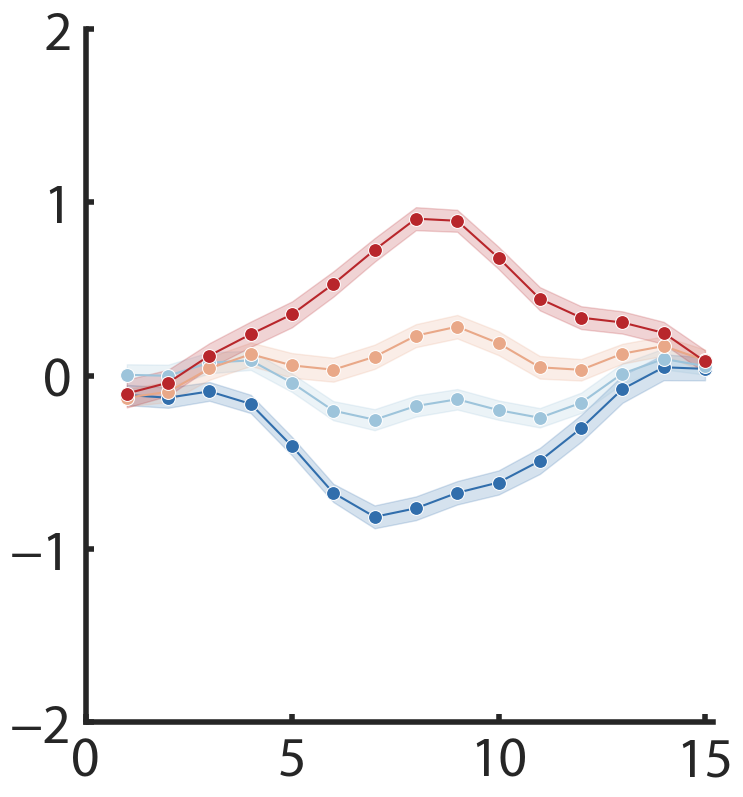

In [23]:
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(7,8)},font=prop.get_name())
fig, ax = plt.subplots(figsize=(9*0.9,9))  
sns.lineplot(x="TSlvls", y="TSlvl1", data=df_TSpre_g2,marker="o",markersize=10,errorbar='se',color="#316eac")
sns.lineplot(x="TSlvls", y="TSlvl2", data=df_TSpre_g2,marker="o",markersize=10, errorbar='se',color="#9dc4db")
sns.lineplot(x="TSlvls", y="TSlvl3", data=df_TSpre_g2,marker="o",markersize=10,errorbar='se',color="#e9a888")
sns.lineplot(x="TSlvls", y="TSlvl4", data=df_TSpre_g2,marker="o",markersize=10,errorbar='se',color="#b8262b")
ax.set(xlabel='', ylabel='')
ax.set(ylim=(-2,2), yticks=[-2,-1,0,1,2])
ax.set(xlim=(0,15.2), xticks=[0,5,10,15])
ax.tick_params(axis="y",direction="in", pad=10, labelsize=40)
ax.tick_params(axis="x",direction="in", pad=10, labelsize=40)
ax.spines['bottom'].set_linewidth(4)
ax.spines['left'].set_linewidth(4)
ax.tick_params(width=4)
sns.despine()

## Cross prediction

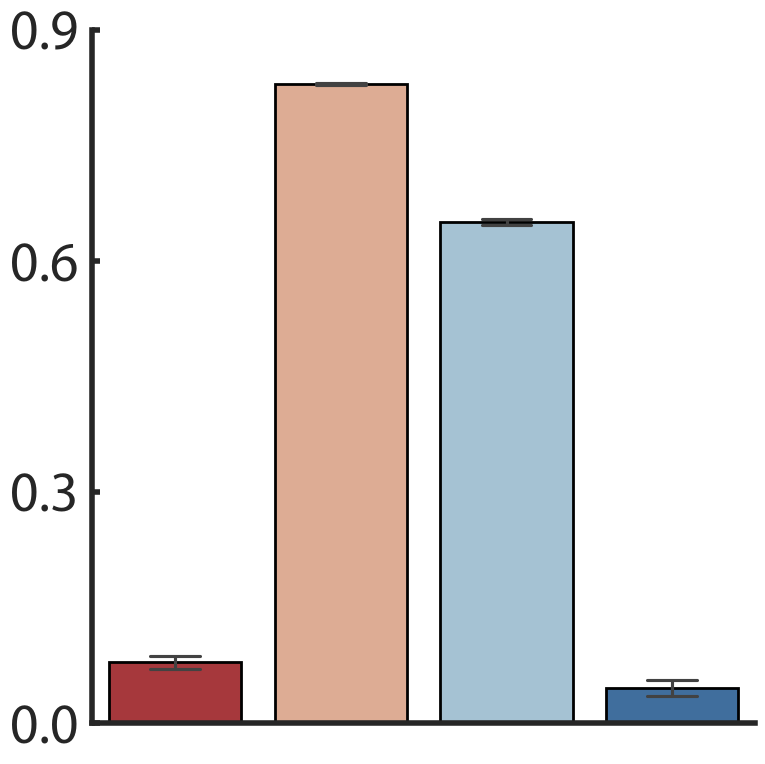

In [24]:
## Cross prediction
cvdata = sio.loadmat('Figure_data/crossprediction_validation.mat')
df_cvp = pd.DataFrame(cvdata['crossprediction_data_plot'])
sns.set_context("talk")
sns.set(font_scale=3, style="ticks", rc={'figure.figsize': (6, 8)}, font=prop.get_name())
barpalette = ["#b8262b", "#e9a888", "#9dc4db", "#316eac"]
fig, ax = plt.subplots(figsize=(9 * 0.95, 9))
#sns.barplot(df_cvp,errorbar=("ci",95),capsize=.3,err_kws={"color": "0", "linewidth": 2}, palette=barpalette)
sns.barplot(df_cvp, errorbar="se", capsize=.3, palette=barpalette)
#g.set_axis_labels("", "Correlation (r)")
for bar in ax.patches:
    bar.set_linewidth(2)
    bar.set_edgecolor('black')

ax.set(xlabel='', ylabel='')
ax.set(xticks=[])
ax.set(ylim=(0, 0.9), yticks=[0, 0.3, 0.6, 0.9])
ax.tick_params(axis="y", direction="in", pad=10, width=4, labelsize=40)
ax.spines['bottom'].set_linewidth(4)
ax.spines['left'].set_linewidth(4)
sns.despine()

## Generalization plot

In [25]:
csf = h5py.File('Figure_data/CosineSimilarityHCP.mat')
generalvalence_data = pd.DataFrame({'Semantic':csf['similarity_generalvalence_map_G1'][0],
                                    'Value':csf['similarity_generalvalence_map_G2'][0]})
placevsface_data = pd.DataFrame({'Semantic':csf['similarity_placevsface_map_G1'][0],
                                    'Value':csf['similarity_placevsface_map_G2'][0]})

/var/folders/2q/v8k7f8yj5jg6mtyx9v4xzr340000gn/T/ipykernel_63592/1918551995.py:3: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 3}` instead.

  sns.barplot(generalvalence_data,errorbar="se",capsize=.3,errwidth=3, palette=["#316eac", "#b8262b"])
/var/folders/2q/v8k7f8yj5jg6mtyx9v4xzr340000gn/T/ipykernel_63592/1918551995.py:5: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.swarmplot(generalvalence_data,size=10,palette=["grey"],alpha=0.5)


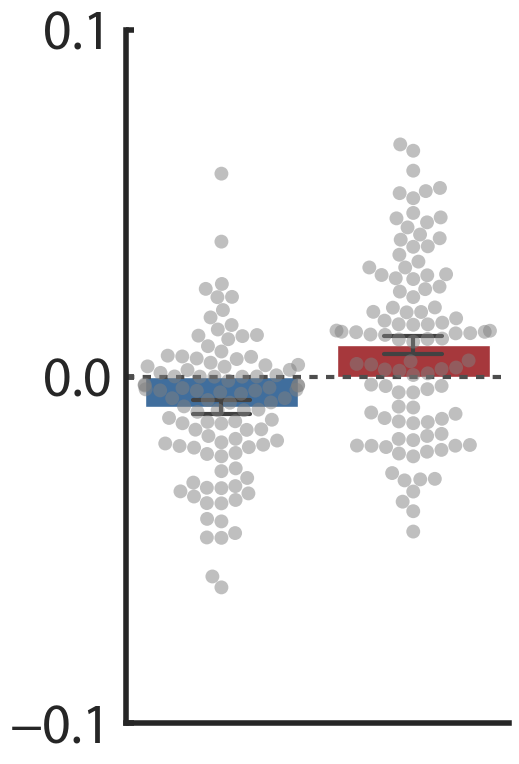

In [26]:
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(6,8)},font=prop.get_name())
fig, ax = plt.subplots(figsize=(9*0.55,9)) 
sns.barplot(generalvalence_data,errorbar="se",capsize=.3,errwidth=3, palette=["#316eac", "#b8262b"])
ax.axhline(0, color=".3", dashes=(2, 2),linewidth=3)
sns.swarmplot(generalvalence_data,size=10,palette=["grey"],alpha=0.5)
ax.set(xlabel='', ylabel='')
ax.set(ylim=(-0.1,0.1), yticks=[-0.1,0,0.1])
ax.set(xticks=[])
ax.tick_params(axis="y",direction="in", pad=10, labelsize=40)
ax.tick_params(axis="x",direction="in", pad=10, labelsize=40)
ax.spines['bottom'].set_linewidth(4)
ax.spines['left'].set_linewidth(4)
ax.tick_params(width=4)
sns.despine()

/var/folders/2q/v8k7f8yj5jg6mtyx9v4xzr340000gn/T/ipykernel_63592/1896357583.py:3: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 3}` instead.

  sns.barplot(placevsface_data,errorbar="se",capsize=.3,errwidth=3, palette=["#e9a888", "#9dc4db"])
/var/folders/2q/v8k7f8yj5jg6mtyx9v4xzr340000gn/T/ipykernel_63592/1896357583.py:5: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.swarmplot(placevsface_data, size=10,palette=["grey"],alpha=0.5)


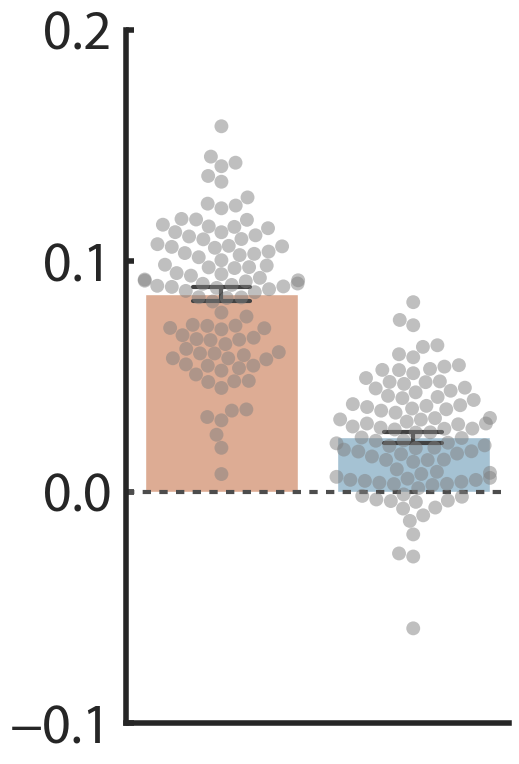

In [27]:
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(6,8)},font=prop.get_name())
fig, ax = plt.subplots(figsize=(9*0.55,9)) 
sns.barplot(placevsface_data,errorbar="se",capsize=.3,errwidth=3, palette=["#e9a888", "#9dc4db"])
ax.axhline(0, color=".3", dashes=(2, 2),linewidth=3)
sns.swarmplot(placevsface_data, size=10,palette=["grey"],alpha=0.5)
ax.set(xlabel='', ylabel='')
ax.set(ylim=(-0.1,0.2), yticks=[-0.1,0,0.1,0.2])
ax.set(xticks=[])
ax.tick_params(axis="y",direction="in", pad=10, labelsize=40)
ax.tick_params(axis="x",direction="in", pad=10, labelsize=40)
ax.spines['bottom'].set_linewidth(4)
ax.spines['left'].set_linewidth(4)
ax.tick_params(width=4)
sns.despine()